In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
envs = ["inverted_pendulum"]
dfs = []
for e in envs:
    for seed in range(10):
        df = pd.read_csv(f"symbolic_{e}_{seed}.csv")
        df["seed"] = str(seed)
        df["env"] = e
        dfs.append(df)
df = pd.concat(dfs)
df.head()

,iteration,loss,reward,mixed_reward,seed,env
0,0,-0.354701,212.90001,1000.0,0,inverted_pendulum
1,1,-0.314038,10.20000,1000.0,0,inverted_pendulum
2,2,-0.352274,1000.00000,1000.0,0,inverted_pendulum
0,0,-0.354146,238.80000,1000.0,1,inverted_pendulum
1,1,-0.313320,10.60000,1000.0,1,inverted_pendulum


/home/gnadizar/miniconda3/envs/gpax311/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gnadizar/miniconda3/envs/gpax311/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gnadizar/miniconda3/envs/gpax311/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key

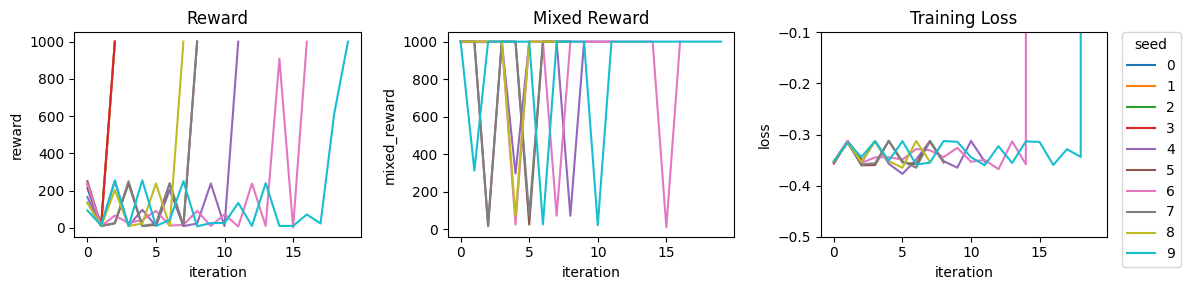

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=True)
palette = dict(zip(df["seed"].unique(), sns.color_palette()))

sns.lineplot(
    data=df,
    x="iteration",
    y="reward",
    hue="seed",
    ax=axes[0],
    palette=palette,
)
axes[0].set_title("Reward")

sns.lineplot(
    data=df,
    x="iteration",
    y="mixed_reward",
    hue="seed",
    ax=axes[1],
    palette=palette,
)
axes[1].set_title("Mixed Reward")

sns.lineplot(
    data=df,
    x="iteration",
    y="loss",
    hue="seed",
    ax=axes[2],
    palette=palette,
)
axes[2].set_ylim(-.5, -.1)
axes[2].set_title("Training Loss")

axes[0].legend_.remove()
axes[1].legend_.remove()
axes[2].legend(
    title="seed",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.tight_layout()
plt.show()